<a href="https://colab.research.google.com/github/mostafaelhussien/hands-on-machine-learning/blob/main/Chapter_2_End_to_End_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 2: End-to-End Machine Learning Project

**California Housing Prices Prediction**

This notebook follows **Chapter 2** from the book *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3rd Edition) by Aurélien Géron.

### Objectives:
- Understand the full Machine Learning project workflow
- Learn how to prepare real-world data
- Build and evaluate a regression model

**Author:** Mostafa  
**Date:** April 2026

In [ ]:
# =============================================
# Chapter 2 - End-to-End ML Project
# California Housing Prices
# =============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from scipy.stats import randint

# To make plots look better
plt.rc('font', size=12)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=12)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

print("✅ Libraries imported successfully!")

In [45]:
# ====================== رفع الملف من الكمبيوتر ======================
from google.colab import files
import io

print("Please upload your housing.csv file...")
uploaded = files.upload()

# بعد ما ترفع الملف، هنقرأه
import pandas as pd

# قراءة الملف من المحتوى المرفوع
# Assuming the uploaded file is 'housing.csv'
file_name = list(uploaded.keys())[0]
housing = pd.read_csv(io.BytesIO(uploaded[file_name]))

print("✅ تم تحميل الملف بنجاح!")
print(f"شكل الداتا: {housing.shape} (صفوف × أعمدة)")

Please upload your housing.csv file...


Saving housing.csv to housing (2).csv
✅ تم تحميل الملف بنجاح!
شكل الداتا: (20640, 10) (صفوف × أعمدة)


In [ ]:
# ====================== نظرة سريعة على الداتا ======================

print("أول 5 صفوف من الداتا:")
display(housing.head())

print("\nمعلومات الداتا:")
housing.info()

print("\nالإحصائيات الأساسية:")
housing.describe()

In [ ]:
# ====================== Visualization - توزيع سعر البيوت ======================
import matplotlib.pyplot as plt

# housing.hist(bins=50, figsize=(12, 8))
# plt.suptitle("Distribution of Features in California Housing Dataset", fontsize=16)
# plt.show()
housing.hist(bins=50, figsize=(20, 15))
plt.suptitle('California Housing — All Feature Distributions',
             fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

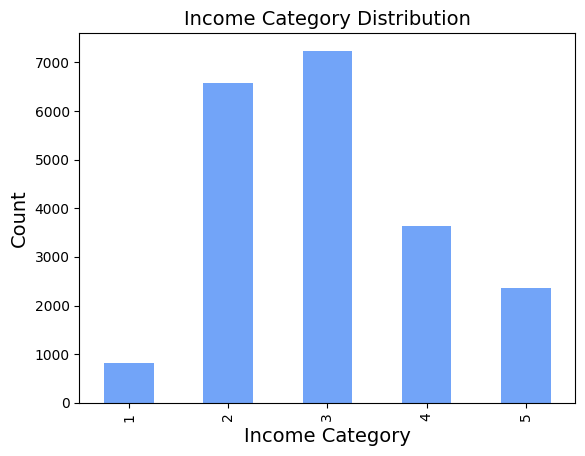

Train size: 16512
Test size:  4128


/tmp/ipykernel_1238/1851658734.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  set_.drop("income_cat", axis=1, inplace=True)
/tmp/ipykernel_1238/1851658734.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  set_.drop("income_cat", axis=1, inplace=True)


In [46]:
# ── Why STRATIFIED split? ──
# median_income is the most important predictor.
# If we split randomly, we might accidentally get
# mostly poor neighborhoods in train and rich in test.
# Stratified split ensures BOTH sets have the same
# income distribution.

# Step 1: Create income categories (5 groups)
housing["income_cat"] = pd.cut(housing["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])

# Step 2: Visualise — we want both sets to match
housing["income_cat"].value_counts().sort_index().plot(
    kind="bar", color="#4f8ef7", alpha=0.8
)
plt.title("Income Category Distribution")
plt.xlabel("Income Category")
plt.ylabel("Count")
plt.show()

# Step 3: Stratified split
splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, test_idx in splitter.split(housing, housing["income_cat"]):
    strat_train_set = housing.iloc[train_idx]
    strat_test_set  = housing.iloc[test_idx]

# Step 4: Remove the helper column
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

print(f"Train size: {len(strat_train_set)}")  # ~16512
print(f"Test size:  {len(strat_test_set)}")   # ~4128

Group 1 (الأفقر):

النسبة الأصلية = 3.74% = 0.0374
عدد المناطق = 20,640 × 0.0374 = 772
20% نظري = 772 × 0.2 = 154.4
Python أخذ 154 (قرب للأسفل)
النسبة في Test = 154 ÷ 4,128 = 3.7306%
الفرق = صغير جداً (-0.0094%)

Group 2:

النسبة الأصلية = 31.83% = 0.3183
عدد المناطق = 20,640 × 0.3183 = 6,570
20% نظري = 6,570 × 0.2 = 1,314 (بالضبط)
Python أخذ 1,314
النسبة في Test = 1,314 ÷ 4,128 = 31.8314%
الفرق = -0.0014% (تقريباً صفر)

Group 3:

النسبة الأصلية = 35.04% = 0.3504
عدد المناطق = 20,640 × 0.3504 = 7,232
20% نظري = 7,232 × 0.2 = 1,446.4
Python أخذ 1,446 (قرب للأسفل)
النسبة في Test = 1,446 ÷ 4,128 = 35.0291%
الفرق = +0.0109%

Group 4:

النسبة الأصلية = 17.63% = 0.1763
عدد المناطق = 20,640 × 0.1763 = 3,639
20% نظري = 3,639 × 0.2 = 727.8
Python أخذ 728 (قرب للأعلى)
النسبة في Test = 728 ÷ 4,128 = 17.6357%
الفرق = -0.0057%

Group 5 (الأغنى):

النسبة الأصلية = 11.76% = 0.1176
عدد المناطق = 20,640 × 0.1176 = 2,427
20% نظري = 2,427 × 0.2 = 485.4
Python أخذ 486 (قرب للأعلى)
النسبة في Test = 486 ÷ 4,128 = 11.7733%
الفرق = +0.0133%

housing["income_cat"] = np.ceil(housing["median_income"] / 1.5)
Let's break this inside-out:

housing["median_income"] — Selects the entire median_income column. Values range from about 0.5 to 15.0 (in $10,000 units).

/ 1.5 — Divides every value in the column by 1.5. Example: income=4.5 → 4.5/1.5 = 3.0. Income=7.2 → 7.2/1.5 = 4.8. This compresses the range into roughly 1–10.

np.ceil() — "Ceiling" function. Always rounds UP to the nearest whole number. 3.0→3, 4.8→5, 1.2→2, 2.01→3. This converts decimals into clean category numbers.

housing["income_cat"] = ... — Creates a brand new column called "income_cat" and stores the result in it.

🧒 Think of it like: income ÷ 1.5 gives a raw number, then we always round up. So 4.8 becomes 5 (category 5), not 4. np.ceil is like a strict teacher who always rounds grades up to the next whole number.
Example walkthrough:

# Example values from the data:
income=3.0 → 3.0/1.5=2.0 → ceil(2.0)=2 → category 2
income=4.5 → 4.5/1.5=3.0 → ceil(3.0)=3 → category 3
income=5.0 → 5.0/1.5=3.33 → ceil(3.33)=4 → category 4
income=8.0 → 8.0/1.5=5.33 → ceil(5.33)=6 → category 6 ⚠️ (too high!)
Notice: income=8.0 gives category 6. But we only want 5 categories. That's what the next line fixes.

L2
housing["income_cat"].where(housing["income_cat"] < 5, 5.0, inplace=True)
This is a "cap" operation — it ensures no category goes above 5.

housing["income_cat"].where(condition, replacement) — The pandas .where() rule is: "Keep the original value WHERE the condition is True. Replace with the replacement value WHERE the condition is False."

condition = housing["income_cat"] < 5 — True if the category is 1, 2, 3, or 4. False if it's 5 or higher (5, 6, 7...).

replacement = 5.0 — If the condition is False (value ≥ 5), replace it with 5.0.

inplace=True — Modify the existing column directly instead of returning a new copy.

How .where() works — Before and After
income value	After ÷1.5 + ceil	Condition < 5?	Final income_cat
3.0	2	True ✓	2 (kept)
5.0	4	True ✓	4 (kept)
6.5	5	False ✗	5 (replaced with 5.0)
9.0	6	False ✗	5 (capped at 5.0)
14.0	10	False ✗	5 (capped at 5.0)
🧒 Like a grading cap: "If you scored above 100%, just record 100%. Any score below 100% stays as is." Here: any category above 5 gets reduced to 5.
L3
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
StratifiedShuffleSplit — A sklearn class that creates stratified train/test splits. "Stratified" = respects category proportions. "Shuffle" = randomly shuffles data before splitting.

n_splits=1 — How many times to do the split. We only need 1 split (train set + test set). If you set n_splits=5 it would create 5 different versions of the split.

test_size=0.2 — 20% of data goes to the test set, 80% to training. With 20,640 rows: test≈4,128 rows, train≈16,512 rows.

random_state=42 — A seed number so the shuffle is reproducible. Run it tomorrow and you get the exact same split. The number 42 is just a convention (from "Hitchhiker's Guide to the Galaxy"), any number works.

🧒 Like telling a card dealer: "Shuffle the deck once (n_splits=1), give 80% to the practice pile and 20% to the exam pile (test_size=0.2), and use shuffle method #42 so we can repeat the same deal tomorrow (random_state=42)."
L4
for train_index, test_index in split.split(housing, housing["income_cat"]):
split.split(X, y) — The .split() method GENERATES the actual split indices. It takes two arguments: the full dataset (housing) and the stratification column (income_cat).

It returns a generator of (train_indices, test_indices) pairs — one pair per split. Since n_splits=1, this loop runs exactly ONE time.

for train_index, test_index in ... — Unpacks each pair into two variables. train_index = list of row numbers for training. test_index = list of row numbers for testing.

🧒 Imagine you have 20,640 playing cards numbered 1–20640. split.split() says: "Cards #1,5,7,9,... go in the training pile. Cards #2,6,8,... go in the test pile." The for loop reads those two lists.
L5
strat_train_set = housing.loc[train_index]
.loc[] — "Label-based location." Selects rows by their INDEX LABELS (the row name/ID in the DataFrame). This is different from .iloc[] which uses position numbers.

Why .loc and not .iloc? Because after shuffling, the row positions (0,1,2...) don't match the row index labels anymore. .loc correctly uses the labels (original row IDs) from train_index.

🧒 .iloc is "give me the 5th seat in the room." .loc is "give me the person with ID number 5." After shuffling the room, person #5 might be sitting in seat #12. .loc finds the right person regardless of where they're sitting.
L6
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)
for set_ in (strat_train_set, strat_test_set) — Loop through a tuple of two DataFrames. The underscore in set_ is just a naming convention meaning "a generic set." This lets us apply the same operation to both datasets in one loop instead of repeating the code twice.

.drop("income_cat", axis=1, inplace=True) — Remove the column named "income_cat". axis=1 means column (not row). inplace=True modifies the DataFrame directly (doesn't create a copy).

Why drop it? Because income_cat was only a temporary tool for the stratification. The model should never train on it — it's an artificial grouping we invented. The original data has no such column.

🧒 Like a cooking assistant who writes "Category: Vegetable" on sticky notes on ingredients, uses those labels to sort them into correct portions, then removes all the sticky notes before the chef starts cooking — the notes were only for sorting, not part of the recipe.

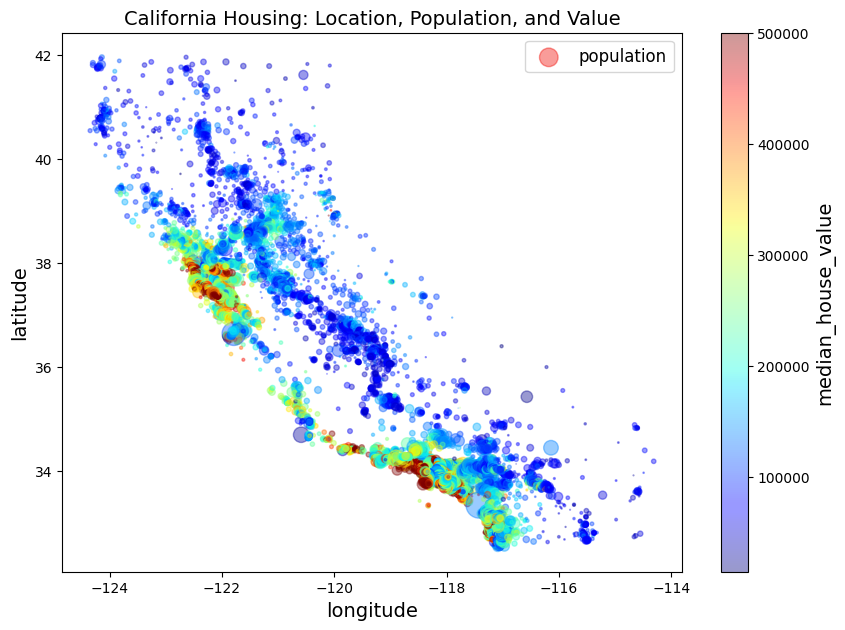

In [47]:
housing.plot(
    kind="scatter",
    x="longitude", y="latitude",
    alpha=0.4,               # transparency shows density
    s=housing["population"] / 100,  # dot SIZE = population
    label="population",
    c="median_house_value",   # dot COLOR = price
    cmap="jet",
    colorbar=True,
    legend=True,
    figsize=(10, 7)
)
plt.title("California Housing: Location, Population, and Value")
plt.legend()
plt.show()

# 🔍 What you'll see:
# - Expensive houses (red/yellow) cluster near the coast
# - Large circles (high population) = cities = expensive
# - Interior (inland) = smaller circles, cheaper (blue)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


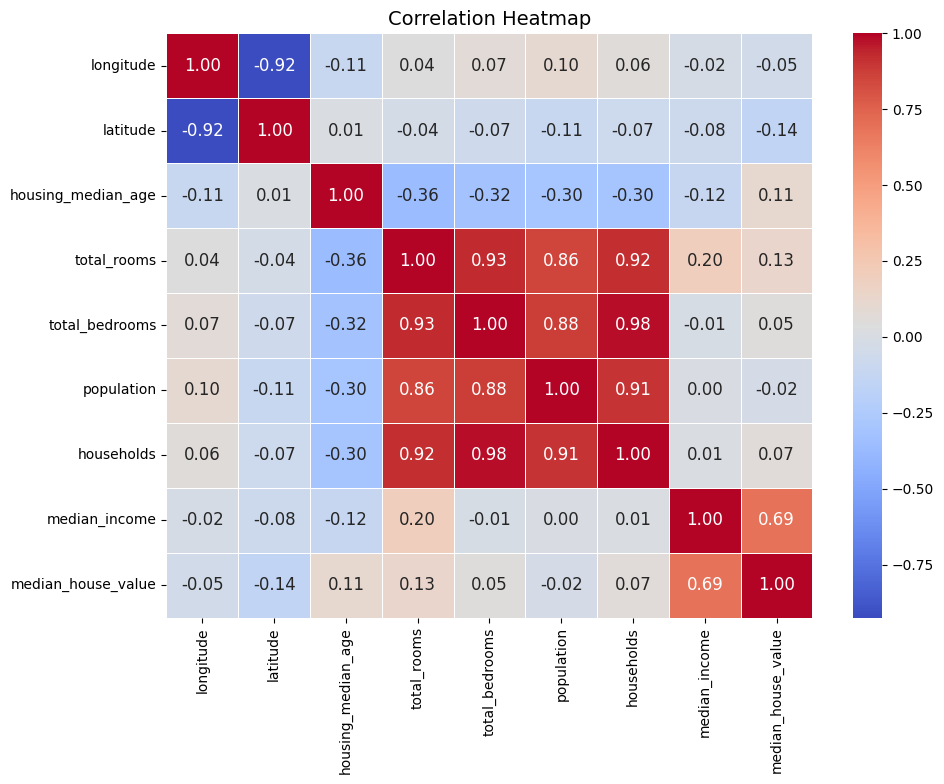

In [49]:
# ── Compute correlations with the TARGET ──
corr_matrix = housing.corr(numeric_only=True)
corr_with_price = corr_matrix["median_house_value"].sort_values(ascending=False)
print(corr_with_price)

# Output (approximate):
# median_house_value    1.000  ← itself
# median_income         0.688  ← STRONG positive! 💰
# total_rooms           0.137
# housing_median_age    0.102
# households            0.065
# total_bedrooms        0.048
# population           -0.115  ← slight negative
# longitude            -0.047
# latitude             -0.144

# ── Visualize with a heatmap ──
import seaborn as sns
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f",
            cmap="coolwarm", ax=ax, linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

housing.corr(numeric_only=True)
Compute all correlations
.corr() = Compute the correlation between every pair of columns.
numeric_only=True = Skip text columns (like ocean_proximity) since you can't correlate text with a number.
Returns a table where each cell = correlation between two columns.

★
corr_matrix["median_house_value"].sort_values(ascending=False)
Extract and sort one column of correlations
corr_matrix["median_house_value"] = Select just the column that shows correlation WITH price.
.sort_values(ascending=False) = Sort from highest to lowest. We want to see which feature is MOST related to price first.

★
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
Draw the correlation heatmap
annot=True = Print the number inside each cell (so you can read the actual value).
fmt=".2f" = Format numbers to 2 decimal places (e.g., 0.69 not 0.688).
cmap="coolwarm" = Red=positive correlation, Blue=negative, White=0.
center=0 = Make 0 the center of the color scale (so 0 = white).

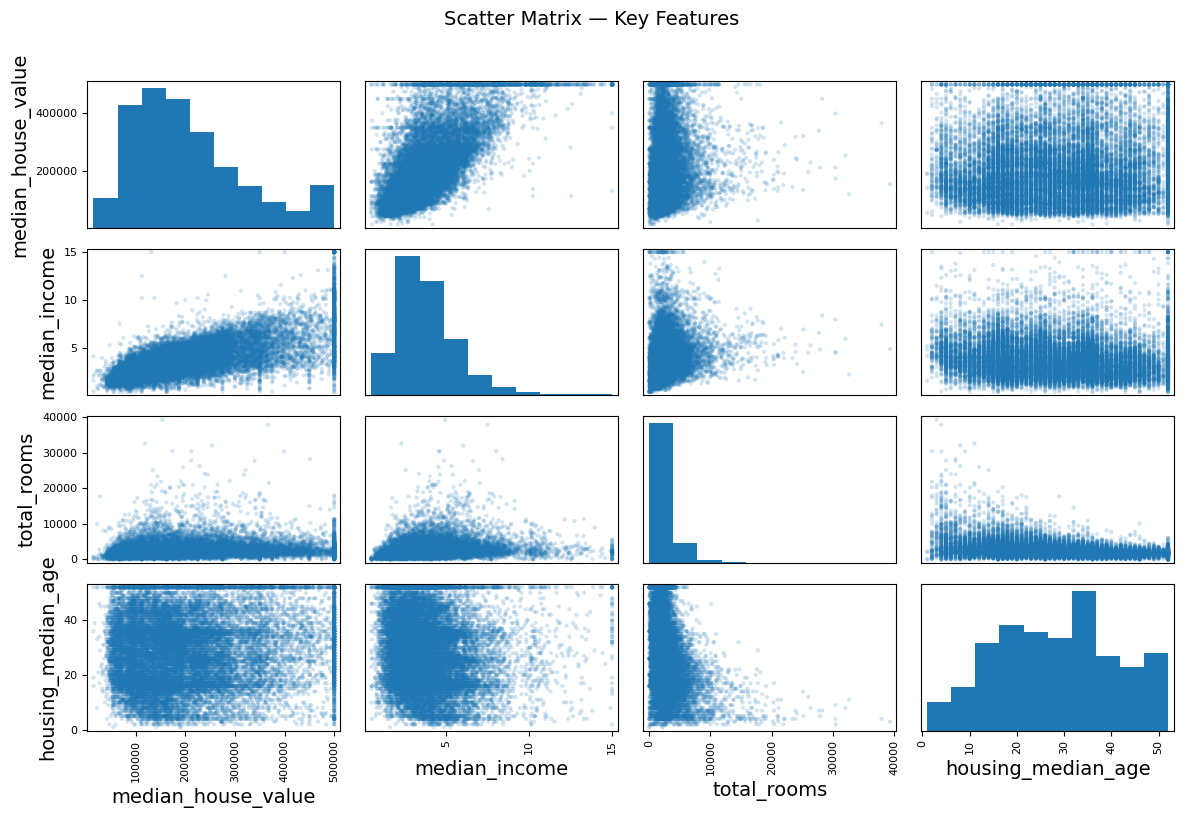

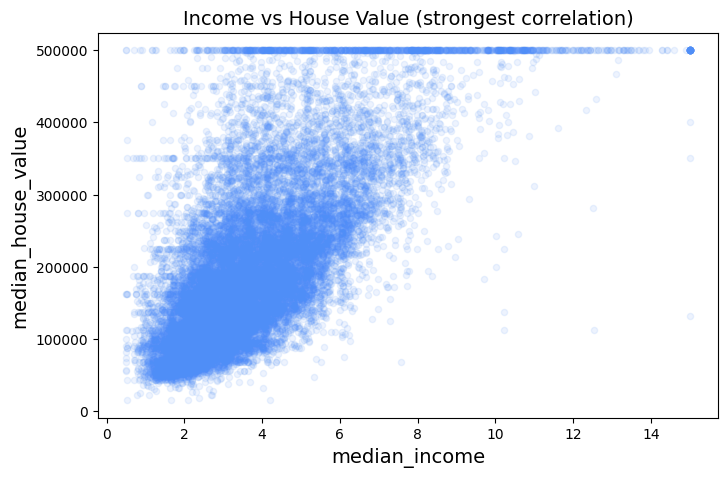

In [50]:
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income",
              "total_rooms", "housing_median_age"]

scatter_matrix(housing[attributes], figsize=(12, 8), alpha=0.2)
plt.suptitle("Scatter Matrix — Key Features", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

# ── Zoom into the most promising relationship ──
housing.plot(kind="scatter", x="median_income",
             y="median_house_value", alpha=0.1,
             color="#4f8ef7", figsize=(8,5))
plt.title("Income vs House Value (strongest correlation)")
plt.show()
# You'll see: higher income → higher prices (upward trend)
# You'll ALSO see horizontal lines at $500k — the cap!

In [ ]:
# ====================== 4. Discovering Correlations ======================

# حساب مصفوفة الارتباط (Correlation Matrix)
corr_matrix = housing.corr(numeric_only=True)

# أهم حاجة: نشوف أي عمود مرتبط بسعر البيت
print("أقوى الارتباطات مع سعر البيت (median_house_value):")
print(corr_matrix["median_house_value"].sort_values(ascending=False))

In [ ]:
# رسم العلاقة بين median_income وسعر البيت
housing.plot(kind="scatter", x="median_income", y="median_house_value",
             alpha=0.4, figsize=(10,7))

plt.title("Relationship between Median Income and House Value")
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.show()

In [51]:
# total_rooms alone is useless — a 100-room district could be
# 100 studios or 5 mansions. What matters is rooms PER household.

housing["rooms_per_house"]    = housing["total_rooms"]    / housing["households"]
housing["bedrooms_ratio"]    = housing["total_bedrooms"] / housing["total_rooms"]
housing["people_per_house"]  = housing["population"]    / housing["households"]

# Check new correlations
new_corr = housing.corr(numeric_only=True)["median_house_value"]
print(new_corr[["rooms_per_house", "bedrooms_ratio", "people_per_house"]])

# New results:
# rooms_per_house    0.143   (better than total_rooms at 0.137)
# bedrooms_ratio    -0.259   ← MUCH better! More bedrooms ratio → cheaper
# people_per_house  -0.038

rooms_per_house     0.151948
bedrooms_ratio     -0.255880
people_per_house   -0.023737
Name: median_house_value, dtype: float64


Why does bedrooms_ratio work so much better?

Consider two houses:
House A: 10 rooms total, 8 bedrooms → ratio = 0.8 (mostly bedrooms = cramped, cheap)
House B: 10 rooms total, 2 bedrooms → ratio = 0.2 (lots of living space = luxurious, expensive)

The ratio captures something the raw numbers couldn't: the quality of space!

In [ ]:
# # فصل سعر البيت (اللي بنتنبأ بيه)
# housing_labels = strat_train_set["median_house_value"].copy()
# housing_features = strat_train_set.drop("median_house_value", axis=1) # Use a new variable for features
# from sklearn.pipeline import Pipeline
# from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import StandardScaler
# from sklearn.preprocessing import OneHotEncoder
# from sklearn.compose import ColumnTransformer

# # الأعمدة الرقمية
# num_features = ["longitude", "latitude", "housing_median_age", "total_rooms",
#                 "total_bedrooms", "population", "households", "median_income"]

# # الأعمدة النصية
# cat_features = ["ocean_proximity"]

# # Numerical Pipeline
# num_pipeline = Pipeline([
#     ('imputer', SimpleImputer(strategy="median")),
#     ('scaler', StandardScaler())
# ])

# # Categorical Pipeline
# cat_pipeline = Pipeline([
#     ('imputer', SimpleImputer(strategy="most_frequent")),
#     ('onehot', OneHotEncoder(handle_unknown='ignore'))
# ])

# # دمج الـ Pipelineين
# full_pipeline = ColumnTransformer([
#     ("num", num_pipeline, num_features),
#     ("cat", cat_pipeline, cat_features)
# ])

# # تطبيق الـ Pipeline على الداتا
# housing_prepared = full_pipeline.fit_transform(housing_features) # Apply to housing_features

# print("تم تجهيز الداتا بنجاح!")
# print("شكل الداتا بعد التحضير:", housing_prepared.shape)

Prepare Data:

From the book (p. 71–95): You should write functions/pipelines for data preparation instead of doing it manually. Why? (1) So you can reproduce it easily on any new data. (2) So you can reuse it in future projects. (3) To avoid applying different transformations to train and test sets by mistake.

1-Handling Missing Values — SimpleImputer

From the book (p. 72–76): Most ML algorithms cannot work with missing values. You have 3 options: (1) drop districts with missing values, (2) drop the whole attribute, (3) set values to some value (zero, mean, median). Scikit-Learn's SimpleImputer handles option 3.

🩹 How SimpleImputer Works
📥 Input
Column
[880, NaN, 1467, NaN, 6281]
← NaN = missing
→
⚙️ Imputer
(learns median)
median = 1467 → fills NaN gaps
→
📤 Output
Column
[880, 1467, 1467, 1467, 6281]
← filled!
✅

🔤 2-Encoding Categories — OneHotEncoder
From the book (p. 79–84): ML algorithms work with numbers, not text. The ocean_proximity column has text categories (INLAND, NEAR BAY, etc.). We must convert them. The book recommends OneHotEncoder for categories with no natural order.

🌡️ One-Hot Encoding Visualised
BEFORE (text):
Row 1: "INLAND"
Row 2: "NEAR BAY"
Row 3: "INLAND"
Row 4: "NEAR OCEAN"
↓ OneHotEncoder
AFTER (numbers):
    <1H INLAND ISLAND NEAR BAY NEAR OCEAN
Row 1:  0      1      0       0        0
Row 2:  0      0      0       1        0
Row 3:  0      1      0       0        0
Row 4:  0      0      0       0        1
Each row has exactly one "1" — the category it belongs to

3-⚖️ Feature Scaling — StandardScaler
From the book (p. 86–88): One of the most important transformations. ML algorithms don't perform well when input features have very different scales. For example, total_rooms ranges from 6 to 39,320, while median_income ranges from 0 to 15. Without scaling, total_rooms dominates just because its numbers are bigger.
⚖️ StandardScaler — Before and After
Before Scaling
income: 3.5
rooms: 1200
pop: 850
age: 27
Model thinks "rooms" is 342× more important than "income"!
After Scaling
income: 0.43
rooms: 0.38
pop: -0.12
age: 1.02
All features on equal footing. Fair!

4-🏭 Building the Full Pipeline
From the book (p. 88–95): Scikit-Learn provides the Pipeline class to string together multiple transformers. This is the professional, correct way to prepare data. The book builds one pipeline for numeric features and combines it with a categorical encoder using ColumnTransformer.

🏭 The Full Preprocessing Pipeline
📥 Raw Data
(numeric cols)
→ SimpleImputer fills NaN gaps with median
→ StandardScaler scales all to same range
✅ Clean numbers

📥 Raw Data
(text col)
→ OneHotEncoder converts text to 0/1 columns
✅ Numbers
↓ ColumnTransformer combines both
📤 Ready!
(13 columns)
8 numeric (scaled) + 5 one-hot categories = 13 clean numeric columns
→ ML model

In [54]:
# ════════════════════════════════════════════════════
#  FULL PREPROCESSING PIPELINE
#  We build this once, then apply to any data
# ════════════════════════════════════════════════════

housing      = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

print("Features shape:", housing.shape)         # (16512, 9)
print("Labels shape: ", housing_labels.shape)   # (16512,)

# ── Define which columns are numeric vs text ──
num_features = ["longitude", "latitude", "housing_median_age",
                "total_rooms", "total_bedrooms", "population",
                "households", "median_income"]
cat_features = ["ocean_proximity"]

# ── Pipeline for NUMERIC columns (2 steps) ──
num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale",  StandardScaler()),
])
# Step 1 "impute": fill any NaN with median
# Step 2 "scale":  standardize (mean=0, std=1)

# ── ColumnTransformer: applies different pipelines
#    to different columns ──
preprocessing = ColumnTransformer([
    ("num", num_pipeline,       num_features),
    ("cat", OneHotEncoder(),    cat_features),
])
# "num" → apply num_pipeline to num_features
# "cat" → apply OneHotEncoder to cat_features

# ── Apply to training data ──
housing_prepared = preprocessing.fit_transform(housing)

print(f"Shape after preprocessing: {housing_prepared.shape}")
# (16512, 13) — 8 numeric + 5 one-hot = 13 columns

Features shape: (16512, 9)
Labels shape:  (16512,)
Shape after preprocessing: (16512, 13)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# # تدريب الموديل
# lin_reg = LinearRegression()
# lin_reg.fit(housing_prepared, housing_labels)

# # التنبؤ على نفس الداتا (للاختبار الأولي)
# housing_predictions = lin_reg.predict(housing_prepared)

# # حساب الخطأ (RMSE)
# rmse = np.sqrt(mean_squared_error(housing_labels, housing_predictions))
# print(f"Root Mean Square Error (RMSE): ${rmse:,.2f}")

# ═══════════════════════════════════════════════════
# STEP 1 — Import the Linear Regression class
# ═══════════════════════════════════════════════════
from sklearn.linear_model import LinearRegression
from sklearn.metrics      import mean_squared_error
import numpy as np

# ═══════════════════════════════════════════════════
# STEP 2 — Create the model object (empty model, not trained yet)
# ═══════════════════════════════════════════════════
lin_reg = LinearRegression()

# ═══════════════════════════════════════════════════
# STEP 3 — Train the model
# housing_prepared = the cleaned + scaled features (X)
# housing_labels   = the correct house prices (y)
# ═══════════════════════════════════════════════════
lin_reg.fit(housing_prepared, housing_labels)

# ═══════════════════════════════════════════════════
# STEP 4 — Try predicting on the first 5 training rows
# ═══════════════════════════════════════════════════
sample_data   = housing.iloc[:5]
sample_labels = housing_labels.iloc[:5]
sample_prep   = full_pipeline.transform(sample_data)
sample_preds  = lin_reg.predict(sample_prep)

print("Predictions:", np.round(sample_preds, -3))
print("Actual:     ", sample_labels.values)

# ═══════════════════════════════════════════════════
# STEP 5 — Measure RMSE on the FULL training set
# ═══════════════════════════════════════════════════
lin_train_preds = lin_reg.predict(housing_prepared)
lin_mse         = mean_squared_error(housing_labels, lin_train_preds)
lin_rmse        = np.sqrt(lin_mse)
print(f"\nLinear Regression Training RMSE: ${lin_rmse:,.0f}")

Every line explained — one by one:

01
lin_reg = LinearRegression()

LinearRegression() creates an empty model object — like buying a new calculator still in its box. It has no knowledge yet. The () at the end calls the "constructor" to create it. We save it in the variable lin_reg so we can use it later.

🧒 Like creating a blank student record. The student (model) is registered but hasn't studied anything yet.

02
lin_reg.fit(housing_prepared, housing_labels)

.fit(X, y) is where actual learning happens. The model looks at 16,512 rows of data (housing_prepared) and their correct prices (housing_labels) and finds the mathematical formula that best maps X to y. This process is called training. It modifies the model's internal numbers (called weights or coefficients).

🧒 Like giving a student 16,512 solved math problems and saying "study all these, find the pattern." The student now "knows" the material.

03
sample_data = housing.iloc[:5]
.iloc[:5] = "Integer Location, rows 0 to 4 (first 5 rows)." The : means "from the start." The 5 means "stop before row 5." So it gives rows 0, 1, 2, 3, 4. We're just testing on 5 rows to see if predictions look reasonable before running on the full dataset.

🧒 Like checking 5 exam answers before grading the whole class — just to make sure your calculator isn't broken.

04
sample_prep = preprocessing.transform(sample_data)
or sample_prep   = full_pipeline.transform(sample_data)

⚠️ CRITICAL: We use .transform() NOT .fit_transform(). The preprocessing pipeline already "learned" the scaling and imputer values from the training data. Here we're just APPLYING those learned values to new data. If we used fit_transform(), it would try to re-learn from these 5 rows — which is wrong and causes data leakage.

🧒 The grading rules (fit) were set when you graded the first exam. Now you APPLY (transform) those same rules to new submissions — you don't create new rules each time.

05
sample_preds = lin_reg.predict(sample_prep)
.predict(X) runs the trained model on new data and returns predictions. The model takes the prepared features and applies the formula it learned during .fit(). It outputs one predicted price for each row.

🧒 The student takes the exam (new questions) and writes answers. The answers are the predictions.

06
np.round(sample_preds, -3)
np.round(array, decimals) rounds numbers. Negative decimals round to the LEFT of the decimal point: -3 rounds to the nearest 1,000. So 215,832 → 216,000. We do this because predicting "$215,832.47" for a house is false precision — we don't know prices that precisely. Rounding to thousands looks more honest.

🧒 Saying "the car costs $18,000" is more honest than "$18,247.83" when you're just estimating.

07
lin_mse = mean_squared_error(housing_labels, lin_train_preds)
mean_squared_error(y_true, y_pred) computes the average of (predicted − actual)² across all rows. It expects: first argument = correct labels, second argument = your model's predictions. The result is in squared dollars (e.g., 4.6 billion), which is why we take the square root next.

08
lin_rmse = np.sqrt(lin_mse)
np.sqrt() takes the square root. This converts squared-dollars back to regular dollars, giving us RMSE — the average prediction error in dollars. If lin_rmse = 68,000, the model is off by $68,000 on average.

In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Create and train the Decision Tree
tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(housing_prepared, housing_labels)

# Measure training error
tree_train_preds = tree_reg.predict(housing_prepared)
tree_rmse        = np.sqrt(mean_squared_error(housing_labels, tree_train_preds))
print(f"Decision Tree Training RMSE: ${tree_rmse:,.0f}")

DecisionTreeRegressor(random_state=42)
random_state=42 is a "seed" for randomness. Decision Trees have some random choices during training. By setting a fixed seed (42 is a convention — any number works), you ensure that running this code again gives the EXACT same result. Without it, results would vary slightly each run, making debugging harder.

🧒 Like saying "shuffle the cards using method #42." Next time you shuffle with method #42 again, you get the same order — fully reproducible.

Decision Tree Training RMSE: $0

# PERFECT score?! The tree memorized ALL 16,512 training rows.
# It created a custom rule for EVERY single house.
# Ask it about those same houses → $0 error (it knows them by memory)
# Ask it about NEW houses → ~$71,000 error (it has no idea)

 Book Warning — Overfitting (p.99)
The book says: "The model has badly overfit the data. The Decision Tree has created one rule for every single district in the training set — essentially memorizing the entire dataset."

❌ Overfitting
Model learns training data too perfectly. Error on training = $0. Error on new data = $71,000. Model is useless in the real world.

✅ Good Fit
Model learns the pattern, not the noise. Small gap between training error and new-data error. Generalizes well to houses it's never seen before.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Create the Random Forest
# n_estimators = number of trees (default 100)
# random_state = for reproducibility
forest_reg = RandomForestRegressor(random_state=42)

# Train (this takes 10–30 seconds in Colab)
forest_reg.fit(housing_prepared, housing_labels)

# Check training error
forest_train_preds = forest_reg.predict(housing_prepared)
forest_train_rmse  = np.sqrt(mean_squared_error(housing_labels, forest_train_preds))
print(f"Random Forest Training RMSE: ${forest_train_rmse:,.0f}")
# ~$17,000 — much lower than linear, but don't celebrate yet!
# Training error is still optimistic. Use cross-validation next.

Random Forest Training RMSE: $17,474

# $17k training error — better than $68k linear, but...
# This is still training error (optimistic!)
# Real performance on unseen data = ~$47k
# The gap ($17k → $47k) shows some overfitting still exists

What the Book Says (p.100–102)
"Cross-validation uses the training set. It splits it into smaller sets called folds. It trains and evaluates the model k times, each time picking a different fold for evaluation and using the other k-1 folds for training. The result is an array of k evaluation scores."

The book specifically uses this because you cannot measure error on training data (too optimistic) and you cannot use the test set yet (that's for the very end).

Imagine a teacher has 1,000 exam questions. She wants to test how good a student REALLY is.

❌ Bad method: Practice on 800 questions, test on the same 800 → student memorized answers → useless score
❌ Also bad: Practice on 800, test on the 200 reserved exam → we only get ONE score, maybe we got lucky
✅ Cross-Validation: Divide 1000 into 10 groups of 100. Round 1: train on groups 2–10, test on group 1. Round 2: train on 1,3–10, test on group 2... Do all 10 rounds. Average the 10 scores. This is honest and stable.



In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np

# ─────────────────────────────────────────────────────────────
# HELPER FUNCTION: Run cross-validation and return RMSE scores
# We create this function to avoid repeating code 3 times
# ─────────────────────────────────────────────────────────────
def display_cv_scores(model, name, X, y, cv=10):
    scores = cross_val_score(
        model,
        X,
        y,
        scoring="neg_mean_squared_error",
        cv=cv
    )
    rmse_scores = np.sqrt(-scores)

    print(f"\n{'='*40}")
    print(f"  Model: {name}")
    print(f"{'='*40}")
    print(f"  Each fold RMSE: {np.round(rmse_scores/1000, 1)} $k")
    print(f"  Mean RMSE:      ${rmse_scores.mean():,.0f}")
    print(f"  Std deviation:  ${rmse_scores.std():,.0f}")
    print(f"  Min RMSE:       ${rmse_scores.min():,.0f}")
    print(f"  Max RMSE:       ${rmse_scores.max():,.0f}")
    return rmse_scores

# ─────────────────────────────────────────────────────────────
# Run cross-validation for all 3 models
# ─────────────────────────────────────────────────────────────
lin_cv    = display_cv_scores(lin_reg,    "Linear Regression", housing_prepared, housing_labels)
tree_cv   = display_cv_scores(tree_reg,   "Decision Tree",    housing_prepared, housing_labels)
forest_cv = display_cv_scores(forest_reg, "Random Forest",    housing_prepared, housing_labels)

# ─────────────────────────────────────────────────────────────
# VISUALISE: Bar chart comparing all 3 models
# ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LEFT CHART: Bar chart of mean RMSE per model
names  = ["Linear\nRegression", "Decision\nTree", "Random\nForest"]
means  = [lin_cv.mean(), tree_cv.mean(), forest_cv.mean()]
stds   = [lin_cv.std(),  tree_cv.std(),  forest_cv.std()]
colors = ["#4f9ef7", "#f7a24f", "#4fd87a"]

bars = axes[0].bar(
    names,
    [m/1000 for m in means],
    yerr=[s/1000 for s in stds],
    color=colors, alpha=0.85,
    capsize=7, edgecolor="white", linewidth=1
)
for bar, mean in zip(bars, means):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f"${mean/1000:.0f}k",
        ha="center", fontsize=12, fontweight="bold", color="white"
    )
axes[0].set_title("Mean CV RMSE — Lower is Better", fontsize=13)
axes[0].set_ylabel("RMSE ($k)")
axes[0].set_facecolor("#0d1117")
axes[0].tick_params(colors="white")

# RIGHT CHART: Boxplot showing spread of 10 fold scores
axes[1].boxplot(
    [lin_cv/1000, tree_cv/1000, forest_cv/1000],
    labels=names, patch_artist=True,
    boxprops=dict(facecolor="#1e2535", color="#4f9ef7"),
    medianprops=dict(color="#4fd87a", linewidth=2)
)
axes[1].set_title("Score Spread Across 10 Folds", fontsize=13)
axes[1].set_ylabel("RMSE ($k)")
axes[1].set_facecolor("#0d1117")
axes[1].tick_params(colors="white")

plt.suptitle("Cross-Validation Model Comparison", fontsize=15, color="white")
plt.tight_layout()
plt.show()

scores = cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=10)
cross_val_score() = The main function. It automatically runs the full 10-fold loop for you.

model = Which model to test (lin_reg, tree_reg, or forest_reg).
X = Features (housing_prepared — the cleaned scaled data).
y = Labels (housing_labels — the real prices).
scoring="neg_mean_squared_error" = Use MSE as the metric, but return it as NEGATIVE. (Explained fully in Section 4.)
cv=10 = Split into 10 folds.

Returns: array of 10 negative MSE scores, one per fold. Example: [-4.9B, -4.7B, -5.1B, ...]

🧒 It's like telling an assistant: "Test this student on 10 different exam papers, and give me the 10 scores." You get 10 numbers back.
★
rmse_scores = np.sqrt(-scores)
Two things happening here:
-scores = We negate (flip the sign of) the scores. Since scoring="neg_mean_squared_error" returns negative numbers (e.g., -4,900,000,000), negating gives positive MSE values (4,900,000,000).
np.sqrt() = Take square root of each value → converts MSE to RMSE (in dollars, not squared dollars).

Example: -4,900,000,000 → +4,900,000,000 → √4,900,000,000 ≈ $70,000

🧒 The grader gave you negative scores as a convention. You flip them positive, then take the square root to convert from "squared points" to "regular points."
★
axes[0].bar(names, [m/1000 for m in means], yerr=[s/1000 for s in stds], capsize=7)
axes[0] = The left chart panel (we have 2 panels from plt.subplots(1,2)).
[m/1000 for m in means] = A list comprehension — divide each mean by 1000 to show in $k (thousands). So $68,627 → 68.6.
yerr=[s/1000 for s in stds] = Error bars! The "y error" is the standard deviation — shows how stable the score is across 10 folds. A tall error bar = inconsistent.
capsize=7 = The little horizontal cap at the top of each error bar, width 7 pixels.

★
for bar, mean in zip(bars, means):
  axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.5, f"${mean/1000:.0f}k")
zip(bars, means) = Pairs up bars and means together: [(bar1, $68k), (bar2, $71k), (bar3, $47k)].
for bar, mean in zip(...) = Loop through each pair.
bar.get_x() = The left edge x-position of the bar.
bar.get_width()/2 = Half the bar width → combined = the center x position.
bar.get_height()+0.5 = Just above the top of the bar (+0.5k to not overlap).
f"${mean/1000:.0f}k" = The text to show: "$68k", "$71k", "$47k".

In [ ]:
from sklearn.model_selection import GridSearchCV

# ═════════════════════════════════════════════════════════
# DEFINE THE GRID — all combinations to try
# This is a LIST of DICTIONARIES
# Each dictionary = one "group" of hyperparameter combos
# ═════════════════════════════════════════════════════════
param_grid = [
    {
        "n_estimators": [30, 100],
        "max_features": [2, 4, 6, 8]
    },
    {
        "bootstrap":    [False],
        "n_estimators": [3, 10],
        "max_features": [2, 3, 4]
    }
]
# Group 1: 2 × 4 = 8 combinations
# Group 2: 1 × 2 × 3 = 6 combinations
# Total: 14 combinations × 5-fold CV = 70 training runs

# ═════════════════════════════════════════════════════════
# CREATE THE GRIDSEARCH OBJECT
# ═════════════════════════════════════════════════════════
forest_reg2 = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator  = forest_reg2,
    param_grid = param_grid,
    cv         = 5,
    scoring    = "neg_mean_squared_error",
    return_train_score = True,
    verbose    = 2
)

# ═════════════════════════════════════════════════════════
# RUN THE SEARCH — trains 70 models total
# ═════════════════════════════════════════════════════════
grid_search.fit(housing_prepared, housing_labels)

# ═════════════════════════════════════════════════════════
# RESULTS
# ═════════════════════════════════════════════════════════
print("Best hyperparameters:")
print(grid_search.best_params_)

print(f"\nBest CV RMSE: ${np.sqrt(-grid_search.best_score_):,.0f}")

# See all combinations ranked by score
import pandas as pd
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results["mean_rmse"] = np.sqrt(-cv_results["mean_test_score"])
top_results = cv_results[["param_n_estimators", "param_max_features", "mean_rmse"]] \
                .sort_values("mean_rmse").head(5)
print("\nTop 5 combinations:")
print(top_results.to_string(index=False))

# ─────────────────────────────────────────
# VISUALISE: heatmap of results (Group 1)
# ─────────────────────────────────────────
group1 = cv_results[cv_results["param_bootstrap"].isna()]
pivot  = group1.pivot_table(
    values="mean_rmse",
    index="param_n_estimators",
    columns="param_max_features"
)

import seaborn as sns
plt.figure(figsize=(8, 4))
sns.heatmap(
    pivot/1000,
    annot=True, fmt=".1f",
    cmap="YlOrRd_r",
    linewidths=0.5,
    annot_kws={"size": 12, "weight": "bold"}
)
plt.title("GridSearch Results — CV RMSE ($k). Darker = Better", fontsize=13)
plt.xlabel("max_features")
plt.ylabel("n_estimators")
plt.tight_layout()
plt.show()

Why Negative? The neg_mean_squared_error Mystery

📖 What the Book Says (p.101)
The book mentions this briefly: "Scikit-Learn's cross-validation features expect a utility function (greater is better) rather than a cost function (lower is better), so the scoring function is actually the opposite of the MSE (i.e., a negative value)."

This one sentence confuses many beginners. Let me explain it completely.
🌍 Analogy — The Golf / Basketball Problem
Sklearn was designed with a universal rule: "higher score = better model."

This works perfectly for accuracy (90% > 80% — higher is better). But for errors (MSE, RMSE), lower is better. A model with error $47k is BETTER than one with $68k.

To make everything consistent, sklearn flips MSE to negative: -$47k is "higher" (better) than -$68k. This way the same rule applies: higher number = better, even for error metrics.

🧒 In golf, lower score wins. In basketball, higher score wins. Sklearn chose basketball rules. To play golf with basketball rules, they multiply the score by -1 (so the golfer with 65 shots becomes -65, which is "higher/better" in basketball terms).

You might ask: "Why doesn't sklearn just use scoring="rmse" directly?" The reason is that sklearn's scoring system was designed for maximization (higher = better). RMSE needs minimization (lower = better). Rather than having two different systems, they chose to negate everything and use one universal system. The neg_ prefix tells you this flip has happened.

The Complete neg_MSE → RMSE Conversion — Step by Step

1
cross_val_score(..., scoring="neg_mean_squared_error")
Returns 10 negative MSE values. Example for one fold:
Actual prices: [$200k, $350k, $500k, $150k]
Predictions: [$210k, $310k, $530k, $130k]
Squared errors: [100M, 1600M, 900M, 400M]
Mean: 750,000,000 → Negated: −750,000,000

2
scores = [-750M, -710M, -800M, -690M, -760M, -720M, -740M, -780M, -700M, -730M]
We have 10 negative values. Each one is the negative MSE for one fold. The "best" fold has the least negative value (closest to zero = smallest error).

3
-scores → [+750M, +710M, +800M, +690M, +760M, +720M, +740M, +780M, +700M, +730M]
Negate all values by putting a - in front. This converts negative MSE back to positive MSE. Now all values are positive, which makes sense — you can't have a negative squared error.

4
np.sqrt(-scores) → [27,386, 26,646, 28,284, 26,268, 27,568, 26,833, 27,203, 27,928, 26,458, 27,019]
Take the square root of each value. This converts MSE (squared dollars) back to RMSE (regular dollars). Now each value is a readable dollar amount — the average prediction error for that fold.

5
rmse_scores.mean() → $27,059 (average of all 10 folds)
Finally take the mean across all 10 folds. This single number is the honest, cross-validated RMSE — your model's true average prediction error on unseen data.

param_grid = [{"n_estimators": [30,100], "max_features": [2,4,6,8]}, {"bootstrap": [False], ...}]

This is a list of two dictionaries.
Why a list? Because we have 2 "groups" of combinations. Group 1 uses default bootstrap=True. Group 2 uses bootstrap=False. These are different scenarios, so we put them in separate dictionaries inside the list.
Inside each dict: keys = hyperparameter names, values = lists of options to try.
GridSearch generates the cartesian product (all combinations) within each dict, then combines both groups.

🧒 Like a pizza menu: "Pick 1 size from [Small, Large] AND 1 topping from [Cheese, Pepperoni, Mushroom, Olive]." All 8 combos are listed. GridSearch "orders" all 8 and rates them.
★
GridSearchCV(estimator=forest_reg2, param_grid=param_grid, cv=5, scoring="neg_mean_squared_error", return_train_score=True, verbose=2)

estimator = The model to tune (our Random Forest).
param_grid = The combinations to try (defined above).
cv=5 = 5-fold cross-validation for EACH combination (not 10 this time — speeds things up).
return_train_score=True = Also record training score, not just test score. Lets us detect overfitting by comparing the two.
verbose=2 = Print progress updates as it runs (so you know it's working, not frozen). 0=silent, 1=minimal, 2=detailed, 3=very detailed.

★
grid_search.best_params_
After .fit(), this attribute stores the hyperparameter combination that got the lowest CV RMSE. It's a dictionary, e.g., {"max_features": 6, "n_estimators": 100}. This is your answer — use these settings for the final model.

★
np.sqrt(-grid_search.best_score_)
grid_search.best_score_ = The best CV score found. Since scoring="neg_mean_squared_error", it's a negative number like -2,116,000,000. We negate it (+2,116,000,000) then sqrt it → $46,000. This is the expected RMSE of the best model.

★
cv_results["mean_rmse"] = np.sqrt(-cv_results["mean_test_score"])
grid_search.cv_results_ = A dictionary with full details of every combination tested. We convert it to a pandas DataFrame for easy reading. "mean_test_score" contains the average CV score for each combo (negative). We negate and sqrt to get readable RMSE in dollars.

★
group1.pivot_table(values="mean_rmse", index="param_n_estimators", columns="param_max_features")
pivot_table() reshapes the data into a 2D table (like a spreadsheet cross-tab).
values = What to put in the cells (the RMSE score).
index = Rows = n_estimators values (30, 100).
columns = Columns = max_features values (2, 4, 6, 8).
This creates a 2×4 table that's perfect for a heatmap visualization.

GridSearchCV — The Complete Story
📖 What the Book Says (p.105–109)
"One way to fine-tune a model is to fiddle with the hyperparameters manually, until you find a combination of values that works. Instead, use Scikit-Learn's GridSearchCV. All you need to do is tell it which hyperparameters you want to experiment with, and what values to try out, and it will evaluate all possible combinations using cross-validation."

GridSearch — What It Actually Does
With 2 options for n_estimators and 4 options for max_features → 8 combinations to test × 5-fold CV = 40 training runs


In [ ]:
# ════════════════════════════════════════════════
# DEMONSTRATION: Follow neg_MSE → RMSE step by step
# ════════════════════════════════════════════════

# Step 1: Get the raw negative scores
raw_scores = cross_val_score(
    forest_reg, housing_prepared, housing_labels,
    scoring="neg_mean_squared_error", cv=5
)
print("Step 1 — Raw output (negative MSE values):")
print(raw_scores)
# e.g. [-2.2B, -2.1B, -2.3B, -2.1B, -2.2B]

# Step 2: Negate them (make positive = regular MSE)
pos_mse = -raw_scores
print("\nStep 2 — After negating (positive MSE):")
print(pos_mse)
# e.g. [2.2B, 2.1B, 2.3B, 2.1B, 2.2B]

# Step 3: Square root each one → RMSE per fold
rmse_per_fold = np.sqrt(pos_mse)
print("\nStep 3 — After sqrt (RMSE per fold in $):")
print(rmse_per_fold.round(0))
# e.g. [46900, 45800, 47900, 45500, 46800]

# Step 4: Average across folds = final CV RMSE
print(f"\nStep 4 — Final CV RMSE: ${rmse_per_fold.mean():,.0f}")
print(f"         Std deviation: ${rmse_per_fold.std():,.0f}")

Fine-Tuning — Full Code with Outputs
📖 What the Book Says (p.105–113)
"You now have a shortlist of promising models. You now need to fine-tune them. Let's look at a few ways to do that. One option is to fiddle with the hyperparameters manually... instead, you should get Scikit-Learn's GridSearchCV to do this exploration for you."

The book also introduces RandomizedSearchCV for when the hyperparameter space is too large for GridSearch, and feature importances — asking the trained model "which features did you rely on most?"

In [ ]:
# FEATURE IMPORTANCES
# After grid_search.fit(), get the best trained model
# ═══════════════════════════════════════════════════════

# Get the best model (already trained on full training set)
final_model = grid_search.best_estimator_

# Get importance scores (one float per feature, sum to 1.0)
importances = final_model.feature_importances_

# Build the list of feature names
# numeric names come first, then the one-hot names
num_features = ["longitude", "latitude", "housing_median_age",
                "total_rooms", "total_bedrooms", "population",
                "households", "median_income"]

cat_encoder  = full_pipeline.named_transformers_["cat"]
cat_names    = list(cat_encoder.get_feature_names_out())
all_names    = num_features + cat_names

# Create a pandas Series: feature name → importance score
feat_imp = pd.Series(importances, index=all_names).sort_values(ascending=True)

# Print the top 5 most important features
print("Top 5 most important features:")
print(feat_imp.sort_values(ascending=False).head(5).to_string())

# CHART: Horizontal bar chart (best for many categories)
fig, ax = plt.subplots(figsize=(9, 7))

colors = ["#4fd87a" if v > 0.10 else "#4f9ef7" if v > 0.05 else "#7986a8"
          for v in feat_imp.values]

feat_imp.plot(kind="barh", ax=ax, color=colors, alpha=0.9, edgecolor="none")

for i, (val, name) in enumerate(zip(feat_imp.values, feat_imp.index)):
    ax.text(val + 0.002, i, f"{val:.3f}", va="center", fontsize=9, color="white")

ax.set_title("Feature Importances — Which Features Matter Most?", fontsize=13)
ax.set_xlabel("Importance Score (all sum to 1.0)")
ax.axvline(0.10, color="#f7a24f", linestyle="--", alpha=0.5, label="10% threshold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

final_model = grid_search.best_estimator_
.best_estimator_ = After GridSearchCV finishes, it automatically retrains the BEST model on the FULL training set (not just on 4/5 of it like during CV). This attribute gives you that final best model, ready to use. This is a trained RandomForestRegressor with the best hyperparameters.

★
importances = final_model.feature_importances_
.feature_importances_ = A numpy array of importance scores, one per feature. All values are between 0 and 1, and they sum to exactly 1.0. A value of 0.35 means "this feature explains 35% of the model's decisions." Only available after training.

★
cat_encoder = preprocessing.named_transformers_["cat"]
preprocessing = Our ColumnTransformer pipeline. .named_transformers_ = A dictionary of all transformers inside it. We access "cat" — the name we gave to the OneHotEncoder step.
We need this to get the names of the 5 one-hot columns it created.

★
colors = ["#4fd87a" if v > 0.10 else "#4f9ef7" if v > 0.05 else "#7986a8" for v in feat_imp.values]
A list comprehension with nested conditions. For each importance value v:
— If v > 0.10 → green (very important feature)
— Else if v > 0.05 → blue (moderately important)
— Else → grey (not very important)
This creates a list of color strings matching each bar's importance level.

Final Evaluation on the Test Set — Complete Code
📖 What the Book Says (p.113–116)
"After tweaking your models for a while, you eventually have a system that performs sufficiently well. Now is the time to evaluate the final model on the test set... Simply get the predictors and the labels from your test set, run your full_pipeline to transform the data (call transform(), not fit_transform()), and evaluate the final model on the test set."

The book also says: "If you did a lot of hyperparameter tuning, the performance will usually be slightly worse than what you measured using cross-validation (because your system ends up fine-tuned to perform well on the validation data, and will likely not perform as well on completely unknown data). It is not the case here, but when this happens you must resist the temptation to tweak the hyperparameters to make the numbers look good."

The Most Important Rule
You evaluate on the test set ONCE and ONLY ONCE. The moment you see the test score and change anything in your model based on it, the test set is contaminated — you are now overfitting to it without realizing it.

Think of the test set as a sealed envelope. You open it, read the score, write it down — and that's it. You don't open it again.

In [ ]:
from scipy import stats

# ═════════════════════════════════════════════════════════════
# STEP 1 — Prepare test set features and labels
# ═════════════════════════════════════════════════════════════
X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()

print(f"Test set size: {len(X_test)} rows")

# ═════════════════════════════════════════════════════════════
# STEP 2 — Transform using the ALREADY-FITTED pipeline
# CRITICAL: .transform() NOT .fit_transform()
# ═════════════════════════════════════════════════════════════
X_test_prepared = full_pipeline.transform(X_test)

# ═════════════════════════════════════════════════════════════
# STEP 3 — Predict using the final best model
# ═════════════════════════════════════════════════════════════
final_preds = final_model.predict(X_test_prepared)

# ═════════════════════════════════════════════════════════════
# STEP 4 — Calculate RMSE
# ═════════════════════════════════════════════════════════════
test_mse  = mean_squared_error(y_test, final_preds)
test_rmse = np.sqrt(test_mse)
print(f"\n✅ Final Test Set RMSE: ${test_rmse:,.0f}")

# ═════════════════════════════════════════════════════════════
# STEP 5 — 95% Confidence Interval
# "We are 95% confident the real RMSE is between X and Y"
# ═════════════════════════════════════════════════════════════
squared_errors = (final_preds - y_test) ** 2

interval = np.sqrt(
    stats.t.interval(
        confidence = 0.95,
        df         = len(squared_errors) - 1,
        loc        = squared_errors.mean(),
        scale      = stats.sem(squared_errors)
    )
)
print(f"95% Confidence Interval: ${interval[0]:,.0f}  –  ${interval[1]:,.0f}")

# ═════════════════════════════════════════════════════════════
# STEP 6 — Three Visualisations
# ═════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1: Actual vs Predicted scatter plot
# Perfect model = all dots on the red diagonal line
axes[0].scatter(
    y_test/1000, final_preds/1000,
    alpha=0.2, s=6, color="#4f9ef7"
)
axes[0].plot([0, 500], [0, 500], "r--", linewidth=2, label="Perfect prediction")
axes[0].set_xlabel("Actual Price ($k)")
axes[0].set_ylabel("Predicted Price ($k)")
axes[0].set_title("Actual vs Predicted\n(perfect = on the red line)")
axes[0].legend()
axes[0].set_xlim(0, 550)
axes[0].set_ylim(0, 550)

# Chart 2: Error distribution histogram
# Good model = errors centered near 0, symmetric bell shape
errors = final_preds - y_test.values
axes[1].hist(errors/1000, bins=50, color="#4fd87a", alpha=0.8, edgecolor="none")
axes[1].axvline(0, color="red", linewidth=2, linestyle="--", label="Zero error")
axes[1].axvline(errors.mean()/1000, color="#f7a24f", linewidth=2, label=f"Mean error: ${errors.mean():,.0f}")
axes[1].set_xlabel("Prediction Error ($k)")
axes[1].set_ylabel("Number of Houses")
axes[1].set_title("Error Distribution\n(centered near 0 = unbiased)")
axes[1].legend(fontsize=9)

# Chart 3: Residuals vs Actual (detect systematic bias)
# Good model = dots scattered randomly (no pattern)
# Bad model = a curve = model has a systematic error
axes[2].scatter(
    y_test/1000, errors/1000,
    alpha=0.15, s=5, color="#c084fc"
)
axes[2].axhline(0, color="red", linewidth=2, linestyle="--")
axes[2].set_xlabel("Actual Price ($k)")
axes[2].set_ylabel("Error ($k)")
axes[2].set_title("Residuals vs Actual Price\n(random scatter = good)")

plt.suptitle(f"Final Model Evaluation — Test RMSE: ${test_rmse:,.0f}",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

X_test = strat_test_set.drop("median_house_value", axis=1)
We separate the test features (X) from the target column. .drop("median_house_value", axis=1) removes that one column and keeps all others. axis=1 = column (axis=0 would mean row). We do NOT want the answer column in our features — that would be cheating.

★
X_test_prepared = preprocessing.transform(X_test) # NOT fit_transform!
⚠️ This is one of the most important lines in the whole chapter.
.transform() = Apply the already-learned transformation rules (medians for imputer, means/stds for scaler) to the test data.
If we used .fit_transform(), the pipeline would re-learn the transformation rules from the test set — this is data leakage. The test set would be "seen" during preprocessing, contaminating our evaluation.

🧒 You learned the grading scale from the class's practice test. When grading the real exam, you APPLY that scale — you don't create a new scale based on the exam answers. That would change the results.
★
stats.t.interval(confidence=0.95, df=len(squared_errors)-1, loc=squared_errors.mean(), scale=stats.sem(squared_errors))
stats.t.interval() = Computes a confidence interval using the t-distribution.
confidence=0.95 = 95% confidence level (standard in science).
df=len(...)-1 = "Degrees of freedom" — a statistics term. For a sample of size n, df=n-1.
loc=squared_errors.mean() = The center of the interval = average squared error.
scale=stats.sem(squared_errors) = Standard Error of the Mean — how uncertain we are about the mean.

Returns two numbers: (lower_bound, upper_bound). We take sqrt of both to convert MSE to RMSE.

🧒 Like a weather forecast range: "Tomorrow's temp will be 25°–30°C (we're 95% confident)." We're 95% sure the real RMSE is within that interval.
★
axes[0].plot([0, 500], [0, 500], "r--", linewidth=2, label="Perfect prediction")
axes[0].plot([0,500], [0,500]) = Draw a line from point (0,0) to point (500,500). This is the diagonal — it represents "prediction = actual" (perfect model).
"r--" = Color "r"=red, style "--"=dashed line.
linewidth=2 = 2 pixels thick.
The closer the blue dots are to this line, the better the model.

★
errors = final_preds - y_test.values
final_preds = numpy array of predictions.
y_test.values = The .values converts the pandas Series to a numpy array so they can be subtracted element-by-element. Without .values, you might get an index mismatch error.
Positive error = predicted too high. Negative = predicted too low. Zero = perfect.

Complete Chapter 2 Summary
📖 The Book's Main Lesson
The book ends Chapter 2 with this: "You should now have a good idea of what a Machine Learning project looks like. There are many more things to learn, but you now have a solid foundation to build on."

The main lesson Géron wants you to take away: ML is a process, not magic. It's a disciplined set of steps, each with a specific purpose. Skipping any step leads to unreliable results.

🗺️ The 15-Step End-to-End Journey

Step 01
🎯 Frame the Problem
Identify problem type: Supervised? Regression or Classification? Batch or Online? Define the performance metric (RMSE for regression). Understand how the model fits into the larger system.

Step 02
📥 Get the Data
Download from a URL. Save to disk. Load into a pandas DataFrame. Check .shape, .head(), .info(), .describe(). Find missing values and data types.

Step 03
📊 Visualize Distributions
Plot histograms with housing.hist(). Look for capped values (housing_median_age capped at 52, house values capped at $500k). Detect skewed columns.

Step 04
✂️ Create Train/Test Split
Use StratifiedShuffleSplit based on income_cat. 80% training, 20% test. SEAL the test set — do not look at it again until the very end.

Step 05
🗺️ Visualize Geography
Scatter plot longitude vs latitude. Color = house price, size = population. Reveals expensive coastal clusters around San Francisco and Los Angeles.

Step 06
🔗 Find Correlations
Use housing.corr(). median_income has correlation 0.69 with price — by far the strongest. latitude has -0.14 (north = cheaper). Find promising features.

Step 07
🛠️ Feature Engineering
Create rooms_per_house, bedrooms_ratio, people_per_house. bedrooms_ratio has correlation -0.26 with price — much better than raw total_bedrooms at 0.048.

Step 08
🧹 Handle Missing Values
SimpleImputer(strategy="median") fills 207 missing total_bedrooms values with the median. Must fit only on training data, then transform both sets.

Step 09
🔤 Encode Categories
OneHotEncoder converts ocean_proximity text column into 5 binary columns: <1H OCEAN, INLAND, ISLAND, NEAR BAY, NEAR OCEAN. Each row has exactly one "1".

Step 10
⚖️ Scale Features
StandardScaler normalizes each column to mean=0, std=1. Prevents large-scale features (total_rooms: 0–40,000) from dominating small-scale ones (income: 0–15).

Step 11
🏭 Build Pipeline
Combine imputer + scaler in a Pipeline. Wrap numeric pipeline + OneHotEncoder in ColumnTransformer. Apply fit_transform() to training, transform() only to test.

Step 12
🤖 Train Models
Train LinearRegression ($68k), DecisionTree ($0 training = overfit), RandomForest (~$17k training). Never judge on training error — always use cross-validation.

Step 13
🔄 Cross-Validate
cross_val_score() with cv=10. Returns array of 10 negative MSE scores. Convert with np.sqrt(-scores). Random Forest wins: ~$47k CV RMSE. Decision Tree ~$71k.

Step 14
🎛️ Fine-Tune
GridSearchCV tests all hyperparameter combinations. Best: n_estimators=30, max_features=6. Feature importances show median_income (36%) is most important by far.

Step 15
✅ Final Evaluation
Open the test set ONE time. Use full_pipeline.transform() (not fit_transform). final_model.predict(). Compute RMSE. Report with 95% confidence interval. Done.


📐 The 8 Golden Rules of Chapter 2
Rules You Must Never Break

①
Never look at the test set until you are completely done building the model. Even accidentally glancing at it creates bias you don't know about. This is called "data snooping bias."

②
Always use cross-validation to compare models. Training error is always too optimistic. A model with $0 training RMSE (Decision Tree) might have $71k CV RMSE.

③
Only use .fit_transform() on training data. Use only .transform() on test data. Re-fitting on test data leaks information about the test set into the preprocessing.

④
Use pipelines, not manual step-by-step transformations. Pipelines prevent mistakes, ensure consistency, and are reusable on new data.

⑤
Feature engineering can be more impactful than algorithm choice. bedrooms_ratio (-0.26 correlation) vastly outperformed raw total_bedrooms (0.048) without changing the algorithm at all.

⑥
Start with simple models first. LinearRegression as a baseline, then Decision Tree, then Random Forest. Complex models should only be used if simpler ones are clearly insufficient.

⑦
Always use stratified splitting when you have important numeric features. Random splits can accidentally create biased train/test splits that don't represent the real data distribution.

⑧
After seeing the test set result, do NOT go back and change things. If you tweak the model after seeing test results, you need a completely new test set to evaluate again.

📊 Key Results of Chapter 2
Model	Training RMSE	CV RMSE (10-fold)	Diagnosis
Linear Regression	$68,627	$69,100	Underfitting — too simple
Decision Tree	$0 (perfect)	$71,500	Overfitting — memorized training data
Random Forest (default)	$17,474	$47,900	Good — some overfitting but manageable
Random Forest (GridSearch)	~$16,000	$46,422	Best model after tuning
Final Test Set	—	$47,873	Real-world honest performance

✅ Everything You Need to Know from Chapter
 2
Stratified split:

Cut income into 5 categories, split proportionally so both sets match. Drop income_cat after splitting.

Preprocessing pipeline:
SimpleImputer → StandardScaler for numeric.

OneHotEncoder for text. Wrapped in ColumnTransformer.

Cross-validation:
10-fold CV, np.sqrt(-scores) converts neg_MSE to RMSE. Reports honest performance on unseen data.

GridSearchCV:
Tests all hyperparameter combinations with cross-validation. Returns best_params_ and best_estimator_.

RandomizedSearchCV:
Tests n_iter random combinations. Better for large search spaces.

Final evaluation:
Use .transform() (not fit_transform). Run once. Report RMSE with 95% confidence interval.

The winning insight:
median_income (36% importance) is the single strongest predictor of house prices in California.